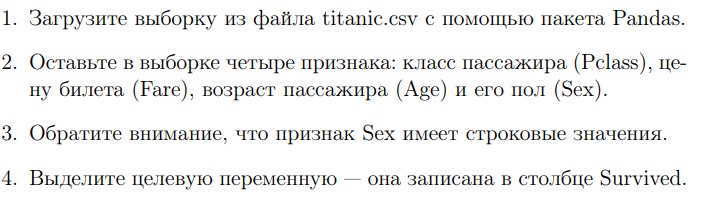

In [9]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('titanic.csv', decimal=',')

# Оставляем четыре признака: Pclass, Fare, Age и Sex
features = ['Pclass', 'Fare', 'Age', 'Sex']
target = 'Survived'

# Создаем новый датафрейм только с нужными признаками и целевой переменной
df_selected = df[features + [target]].copy()

print("Выбранные признаки:")
print(df_selected.head(10))
print("\nФорма датасета после отбора:", df_selected.shape)

Выбранные признаки:
   Pclass     Fare   Age     Sex  Survived
0       3   7.2500  22.0    male         0
1       1  71.2833  38.0  female         1
2       3   7.9250  26.0  female         1
3       1  53.1000  35.0  female         1
4       3   8.0500  35.0    male         0
5       3   8.4583   NaN    male         0
6       1  51.8625  54.0    male         0
7       3  21.0750   2.0    male         0
8       3  11.1333  27.0  female         1
9       2  30.0708  14.0  female         1

Форма датасета после отбора: (891, 5)


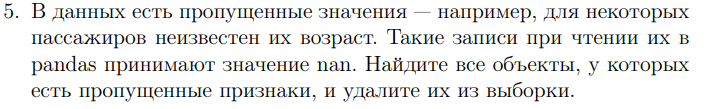

In [10]:
# Проверяем наличие пропущенных значений
print("Количество пропущенных значений в каждом столбце:")
print(df_selected.isnull().sum())
print("\nПроцент пропущенных значений:")
print((df_selected.isnull().sum() / len(df_selected) * 100).round(2))

# Удаляем строки с пропущенными значениями (NaN)
df_clean = df_selected.dropna()

print(f"Форма датасета до удаления пропусков: {df_selected.shape}")
print(f"Форма датасета после удаления пропусков: {df_clean.shape}")
print(f"Удалено строк: {df_selected.shape[0] - df_clean.shape[0]}")

print("\nПроверка отсутствия пропусков:")
print(df_clean.isnull().sum())

Количество пропущенных значений в каждом столбце:
Pclass        0
Fare          0
Age         177
Sex           0
Survived      0
dtype: int64

Процент пропущенных значений:
Pclass       0.00
Fare         0.00
Age         19.87
Sex          0.00
Survived     0.00
dtype: float64
Форма датасета до удаления пропусков: (891, 5)
Форма датасета после удаления пропусков: (714, 5)
Удалено строк: 177

Проверка отсутствия пропусков:
Pclass      0
Fare        0
Age         0
Sex         0
Survived    0
dtype: int64


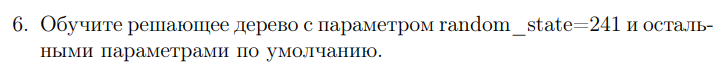

In [11]:
# Информация о признаке Sex (строковые значения)
print("Уникальные значения в столбце Sex:")
print(df_clean['Sex'].unique())
print(f"Количество уникальных значений: {df_clean['Sex'].nunique()}")

# Кодируем строковую переменную Sex в числовую
le = LabelEncoder()
df_clean['Sex_encoded'] = le.fit_transform(df_clean['Sex'])

print(f"\nМаппинг значений Sex:")
for i, value in enumerate(le.classes_):
    print(f"  {value} -> {i}")

# Подготавливаем признаки для обучения
X = df_clean[['Pclass', 'Fare', 'Age', 'Sex_encoded']]
y = df_clean['Survived']

# Переименовываем столбцы для наглядности результатов
X.columns = ['Pclass', 'Fare', 'Age', 'Sex']

print("\nФинальная форма признаков (X):", X.shape)
print("Финальная форма целевой переменной (y):", y.shape)
print("\nПервые 5 строк признаков:")
print(X.head())

# Обучаем решающее дерево с параметром random_state=241
# Остальные параметры оставляем по умолчанию
dt = DecisionTreeClassifier(random_state=241)
dt.fit(X, y)

print("Дерево решений успешно обучено!")
print(f"Глубина дерева: {dt.get_depth()}")
print(f"Количество листьев: {dt.get_n_leaves()}")
print(f"Точность на обучающем наборе: {dt.score(X, y):.4f}")

Уникальные значения в столбце Sex:
['male' 'female']
Количество уникальных значений: 2

Маппинг значений Sex:
  female -> 0
  male -> 1

Финальная форма признаков (X): (714, 4)
Финальная форма целевой переменной (y): (714,)

Первые 5 строк признаков:
   Pclass     Fare   Age  Sex
0       3   7.2500  22.0    1
1       1  71.2833  38.0    0
2       3   7.9250  26.0    0
3       1  53.1000  35.0    0
4       3   8.0500  35.0    1
Дерево решений успешно обучено!
Глубина дерева: 19
Количество листьев: 173
Точность на обучающем наборе: 0.9846


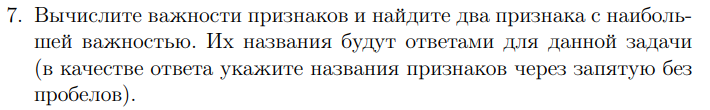

In [20]:
# Получаем важности признаков
feature_importance = dt.feature_importances_

# Создаем датафрейм с важностями признаков
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Важность всех признаков (по убыванию):")
print(importance_df.to_string(index=False))

# Визуализация важности признаков
print("\nВизуализация важности признаков:")
for idx, row in importance_df.iterrows():
    print(f"{row['Feature']:10} |{row['Importance']:.4f}")
    
    # Получаем два признака с наибольшей важностью
top_2_features = importance_df.head(2)['Feature'].tolist()

print("\nРезультаты")

print(f"\nТоп-2 признака по важности:")
for i, feature in enumerate(top_2_features, 1):
    importance_value = importance_df[importance_df['Feature'] == feature]['Importance'].values[0]
    print(f"  {i}. {feature}: {importance_value:.4f}")

# Ответ в требуемом формате
answer = ','.join(top_2_features)
print(f"Ответ: {answer}")


Важность всех признаков (по убыванию):
Feature  Importance
   Fare    0.303436
    Sex    0.300512
    Age    0.256046
 Pclass    0.140005

Визуализация важности признаков:
Fare       |0.3034
Sex        |0.3005
Age        |0.2560
Pclass     |0.1400

Результаты

Топ-2 признака по важности:
  1. Fare: 0.3034
  2. Sex: 0.3005
Ответ: Fare,Sex
